In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.io_utils import (
    save_pickle_file, 
    load_pickle_file,
    save_csv_file, 
    load_csv_file, 
    get_project_path
)

from flonacomldft.internal_coordinates import (
    Coordinates_mapping, 
    get_collective_variables_from_xs
)

In [3]:
def save_accs(adaptives, isomer_name, save_path):
    
    accs = {method: torch.cat( 
        adaptives[method]['accs']
        ).float().mean(dim=1) for method in adaptives.keys()}
    accs_df = pd.DataFrame(accs)

    save_csv_file(accs_df, 
                  'accs_ab-flowMC_{:s}.csv'.format(isomer_name), 
                  save_path)
    
    print('{:s} accs saved!'.format(isomer_name))

    return accs

In [4]:
def save_cvs_energy(adaptives_per_isomer, isomer_name, save_plot_data_path):
    
    cvs_energy_dfs = []

    for method in adaptives_per_isomer.keys():

        us = torch.cat( adaptives_per_isomer[method]['us'] )
        us = us.reshape(us.shape[0], 
                        us.shape[1],
                        1)
        cvs = adaptives_per_isomer[method]['cvs']

        print(cvs.shape, us.shape)

        cvs_energy = torch.cat( (cvs, us), 
                                dim=2 )

        cols = ['Method', 'CV1', 'CV2', 'Potential energy']

        cvs_energy_df = pd.DataFrame(columns=cols)
        cvs_energy_df[cols[1:]] = cvs_energy.reshape(-1, 3).detach().numpy()
        cvs_energy_df[cols[0]] = method

        cvs_energy_dfs.append(cvs_energy_df)

    cvs_energy_df = pd.concat(cvs_energy_dfs)

    save_csv_file(cvs_energy_df,
                'cvs_energy_ab-flowMC_{:s}.csv'.format(isomer_name),
                save_plot_data_path)

    print('{:s} cvs_energy saved!'.format(isomer_name))
                    
    return cvs_energy

# DATA FIGURE 1

In [5]:
# 350K results
torch.manual_seed(42)
project_path = get_project_path()
save_plot_data_path = "data_for_plots"

In [6]:
adaptives_path = [ ['1-adaptive/results_adaptive_is0_29941690/adaptive_sampling_is0_29941690.pkl',
                     '2-adaptive-mlp/results_adaptive_is0_30019620/adaptive_sampling_is0_30019620.pkl'
                     ],
                   ['1-adaptive/results_adaptive_is1_29941694/adaptive_sampling_is1_29941694.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_30019624/adaptive_sampling_is1_30019624.pkl'
                    ] 
                ]

#cvs_path = ['1-adaptive/results_adaptive_is0_29941690/cvs_is0_29941690.pkl',                     
#            '1-adaptive/results_adaptive_is1_29941694/cvs_is1_29941694.pkl'                   
#          ]

methods_name = ['ab-flowMC w.o. NP', 'ab-flowMC']

In [7]:
#adaptives = {i: load_pickle_file(adaptive_path, project_path) for i, adaptive_path in enumerate([adaptives_path[0][0], adaptives_path[1][0]])}

In [8]:
#cvs = {i: load_pickle_file(cvs_path[i], project_path) for i in range(len(cvs_path))}
#cvs[0].shape, cvs[1].shape

In [9]:
#for key in adaptives.keys():
#    xs = torch.cat(adaptives[key]['xs'])
#    isomers = torch.cat(adaptives[key]['isomers'])
#
#    cvs = get_collective_variables_from_xs(xs, isomers)
#
#    save_pickle_file(cvs, cvs_path[key], project_path)


In [10]:
adaptives = {}

for i, adaptives_per_isomer_paths in enumerate(adaptives_path):
    
    adaptives_per_isomer = {}
    
    for method_name, adaptive_path in zip(methods_name, adaptives_per_isomer_paths):
        
        adaptive = load_pickle_file(adaptive_path, project_path)
        adaptives_per_isomer[method_name] = adaptive

        isomer_name, number_id = adaptive_path.split('/')[-2].split('_')[-2:]
        cvs_file_path = '/'.join( adaptive_path.split('/')[:2] + ['cvs_{:s}_{:s}.pkl'.format(isomer_name, number_id)] )

        cvs = load_pickle_file(cvs_file_path, project_path)

        adaptives_per_isomer[method_name]['cvs'] = cvs
    
    adaptives[i] = adaptives_per_isomer

In [11]:
accs_is0 = save_accs(adaptives[0], 'is0', project_path + '/' + save_plot_data_path)
accs_is1 = save_accs(adaptives[1], 'is1', project_path + '/' + save_plot_data_path)

is0 accs saved!
is1 accs saved!


In [12]:
cvs_energy_is0 = save_cvs_energy(adaptives[0], 'is0', project_path + '/' + save_plot_data_path)
cvs_energy_is1 = save_cvs_energy(adaptives[1], 'is1', project_path + '/' + save_plot_data_path)

torch.Size([600, 50, 2]) torch.Size([600, 50, 1])
torch.Size([600, 50, 2]) torch.Size([600, 50, 1])


is0 cvs_energy saved!
torch.Size([600, 50, 2]) torch.Size([600, 50, 1])
torch.Size([600, 50, 2]) torch.Size([600, 50, 1])
is1 cvs_energy saved!


In [13]:
for isomer_label in adaptives:

    mlp_model = adaptives[0][methods_name[1]]['dict_mlps'][-1][0]['model']
    datasets = adaptives[0][methods_name[1]]['mlps_datasets'][0]
    true_values = {dataset_label: datasets[dataset_label][0][:, 12].flatten() for dataset_label in datasets.keys()}
    predict_values = {dataset_label: mlp_model(datasets[dataset_label][0][:, :12]).flatten() for dataset_label in datasets.keys()}

    mlp_dfs = []

    for dataset_label in datasets.keys():
        mlp_df = pd.DataFrame(columns=['Dataset label', 'True values', 'Predict values'])
        mlp_df['True values'] = true_values[dataset_label].detach().numpy()
        mlp_df['Predict values'] = predict_values[dataset_label].detach().numpy()
        mlp_df['Dataset label'] = dataset_label
        mlp_dfs.append(mlp_df)

    mlp_dfs = pd.concat(mlp_dfs, ignore_index=True)

    save_csv_file(mlp_dfs,
                'mlps_datasets_ab-flowMC_is{:d}.csv'.format(isomer_label),
                project_path + '/' + save_plot_data_path)

    print('is{:d} mlp_datasets saved!'.format(isomer_label))                      

is0 mlp_datasets saved!
is1 mlp_datasets saved!


# DATA FIGURE 2

In [48]:
mcmcs_path = ['4-multimodal/results_multimodal_sampling_mixture_30540291/checkpoint_NA_3500.pkl',
            '5-multimodal-mlp/results_multimodal_sampling_mixture_30544251/mixture_mcmc_dic_30544251.pkl'
            ]

cvs_path = ['cvs_slices_30540291_3500.pkl',
            '5-multimodal-mlp/results_multimodal_sampling_mixture_30544251/cvs_mixture_30544251.pkl'
            ]

mcmcs_name = ['ab-flowMM w.o. NP', 'ab-flowMM']

In [49]:
mcmcs = {}

for i in range(len(mcmcs_path)):
    
    mcmc = load_pickle_file(mcmcs_path[i], project_path)
    cvs = load_pickle_file(cvs_path[i], project_path)

    mcmc['cvs'] = cvs
    
    mcmcs[mcmcs_name[i]] = mcmc

In [50]:
cvs_energy_is_dfs = []

for method in mcmcs.keys():

    us = mcmcs[method]['us'][:3500]
    isomers = mcmcs[method]['isomers'][:3500]

    us = us.reshape(us.shape[0], 
                    us.shape[1],
                    1)
    isomers = isomers.reshape(isomers.shape[0],
                                isomers.shape[1],
                                1)
    cvs = mcmcs[method]['cvs'][:3500]

    cvs_energy_is_ = torch.cat( (cvs, us, isomers), 
                            dim=2 )

    cols = ['Method', 'CV1', 'CV2', 'Potential energy', 'Isomer']

    cvs_energy_is_df = pd.DataFrame(columns=cols)
    cvs_energy_is_df[cols[1:]] = cvs_energy_is_.reshape(-1, 4).detach().numpy()
    cvs_energy_is_df[cols[0]] = method

    cvs_energy_is_dfs.append(cvs_energy_is_df)

cvs_energy_is = pd.concat(cvs_energy_is_dfs, ignore_index=True)

In [52]:
cvs_energy_is.to_csv(
    project_path + '/' + save_plot_data_path + '/cvs_energy_is_ab-flowMM.csv', 
    index=False)

In [53]:
isomers_dfs = []

for method in mcmcs.keys():

    isomers = mcmcs[method]['isomers'][:3500]
    chains = [str(i) for i in range(isomers.shape[1])]
    isomers_df = pd.DataFrame(columns=['Method']+chains)
    isomers_df[chains] = isomers.detach().numpy()
    isomers_df['Method'] = method

    isomers_dfs.append(isomers_df)

isomers_df = pd.concat(isomers_dfs, ignore_index=True)

In [54]:
isomers_df.to_csv(
    project_path + '/' + save_plot_data_path + '/isomers_ab-flowMM.csv', 
    index=False)

In [55]:
from flonacomldft.models.mixture import Mixture

In [56]:
mixture_models = {}

for method_adaptive, method_mcmc in zip(methods_name, mcmcs_name):
    
    models = []

    for isomer_label in adaptives.keys():

        model = adaptives[isomer_label][method_adaptive]['dict_flows'][15][0]['model']
        models.append(model)

    mixture = Mixture(models, torch.tensor([0.75, 0.25]))

    mixture_models[method_mcmc] = mixture

In [57]:
N = 2500

density_samples_dfs = []

for method_mcmc in mcmcs_name:

    samples, isomers = mixture_models[method_mcmc].sample(N, return_mus=True)
    isomers = isomers.reshape(-1, 1)
    
    nll = mixture_models[method_mcmc].nll(samples).reshape(-1, 1)
    cvs = get_collective_variables_from_xs(samples.reshape(N, 1, 12), 
                                        isomers)
    density_samples = torch.cat((cvs.squeeze(), nll, isomers), dim=1).detach().numpy()

    cols = ['Method', 'CV1', 'CV2', 'LL', 'Isomer']

    density_samples_df = pd.DataFrame(columns=cols)
    density_samples_df[cols[1:]] = density_samples
    density_samples_df[cols[0]] = method_mcmc

    density_samples_dfs.append(density_samples_df)

density_samples_dfs = pd.concat(density_samples_dfs, ignore_index=True)

In [58]:
save_csv_file(density_samples_dfs,
            'density_samples_ab-flowMM.csv',
            project_path + '/' + save_plot_data_path,
            index=False)

print('density_samples mixtures saved!')

density_samples mixtures saved!


In [59]:
import seaborn as sns

<AxesSubplot:xlabel='CV1', ylabel='CV2'>

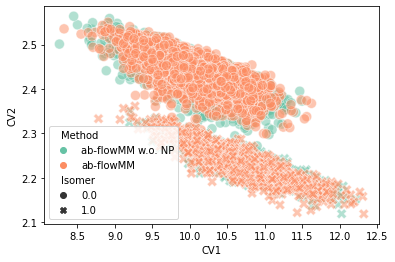

In [60]:
sns.scatterplot(density_samples_dfs,
                x='CV1', 
                y='CV2', 
                hue='Method', 
                style='Isomer',
                palette='Set2',
                s=100,
                alpha=0.5)